# HydrAI: ML Training Data Generation

This notebook generates training datasets for ML surrogate models by running multiple PFR simulations with varied parameters.

## Overview

The data generation process:
1. **Parameter Sweep**: Varies 6 key parameters (temperature, pressure, geometry, flow, heat flux)
2. **Multiple Reactants**: Supports ethane, propane, naphtha, n-hexane
**Efficient Collection**: Disables plots by default; optional duplicate export as CSV (`save_complete_csv`)
4. **Periodic Saves**: Saves data incrementally to prevent loss
5. **Rich Features**: Collects 245+ features per simulation point

## Features
- Configurable parameter ranges
- Latin Hypercube Sampling (LHS) for efficient parameter space coverage
- Random or full-grid sampling alternatives
- Progress tracking and time estimates
- Automatic data validation
- Metadata export for reproducibility

In [1]:
# Setup and Imports
import sys
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime

# Project root: notebooks live under notebooks/; from there, project root is one level up
current_dir = Path(os.getcwd())
if (current_dir / 'src').exists():
    project_root = current_dir
elif (current_dir.parent / 'src').exists():
    project_root = current_dir.parent
else:
    project_root = current_dir
os.chdir(project_root)  # so configs/, data/training/, mechanisms/ resolve correctly

# IMPORTANT: Import cantera BEFORE adding src to sys.path
# This prevents namespace conflict: without this, Python would find src/cantera/
# (our package) instead of the actual cantera library
import cantera as ct
print(f"Cantera version: {ct.__version__}")

# Suppress all Cantera/SUNDIALS warnings and messages
import warnings
import logging

# Add project root to path (after cantera is imported)
sys.path.insert(0, str(project_root))

from src.ml.data_generation import TrainingDataGenerator

print("HydrAI: ML Training Data Generation")
print("=" * 60)
print(f"Project root: {project_root}")

# Run control flags (plots and metadata)
IF_SHOW_PLOTS = True   # Show training-space plots in notebook
IF_SAVE_PLOTS = True  # Save training-space plots to output_dir
IF_SAVE_METADATA = True  # Save metadata JSON when generating dataset
IF_SAVE_TRAINING_DATA = True  # Save training data (partial + final .pkl) to output_dir
IF_SAVE_COMPLETE_CSV = True   # Also write training_data_complete_*.csv (large); optional


Cantera version: 3.1.0
HydrAI: ML Training Data Generation
Project root: c:\35 PYRO_MEANLINE\HydrAI


## Step 1: Configuration

Configure the data generation parameters. You can either:
- Load from a JSON config file
- Set parameters directly in the notebook

**Sampling method**: `latin` (LHS), `random`, or `full_grid` / `structured_grid` / `grid`. Use `parameter_ranges` for grid; use `random_sample_bounds` for random/LHS.

In [2]:
# Load configuration from JSON (edit configs/ml/ml_data_generation_config.json)
CONFIG_FILE = 'configs/ml/ml_data_generation_config.json'

if not Path(CONFIG_FILE).exists():
    raise FileNotFoundError(f"Config not found: {CONFIG_FILE}")

with open(CONFIG_FILE, 'r') as f:
    config = json.load(f)
print(f"[OK] Loaded configuration from: {CONFIG_FILE}")

REACTANTS = config.get('reactants', ['ethane'])
MAX_COMBINATIONS = config.get('max_combinations_per_reactant', 100)
OUTPUT_DIR = config.get('output_dir', 'data/training')
SAVE_INTERVAL = config.get('save_interval', 10)
PARAM_RANGES = config.get('parameter_ranges', {})
SAMPLING_METHOD = config.get('sampling_method', 'latin_hypercube')
LHS_SEED = config.get('lhs_seed', 42)
RANDOM_SAMPLE_BOUNDS = config.get('random_sample_bounds', None)

print(f"  - Reactants: {REACTANTS}")
print(f"  - Max combinations per reactant: {MAX_COMBINATIONS}")
print(f"  - Output directory: {OUTPUT_DIR}")
print(f"  - Sampling method: {SAMPLING_METHOD}")

print(f"\nParameter Ranges:")
for param, values in PARAM_RANGES.items():
    if isinstance(values, list) and len(values) == 3:
        print(f"  - {param}: {values[0]} to {values[1]} ({values[2]} points)")
    else:
        print(f"  - {param}: {values}")

[OK] Loaded configuration from: configs/ml/ml_data_generation_config.json
  - Reactants: ['n-hexane']
  - Max combinations per reactant: 10
  - Output directory: data/training
  - Sampling method: latin

Parameter Ranges:
  - _comment: For grid/structured_grid/full_grid: [min, max, n_points]. Total runs = product of n_points
  - temperature_K: 800 to 900 (10 points)
  - pressure_bar: 1.5 to 3.5 (10 points)
  - length_m: 10.0 to 15.0 (10 points)
  - diameter_mm: 25.0 to 40.0 (10 points)
  - mass_flow_rate_kgps: 0.05 to 0.1 (10 points)
  - heat_flux_Wm2: 100000 to 250000 (10 points)


## Step 2: Initialize Data Generator

Create the data generator with your configuration.

In [3]:
# Initialize generator
generator = TrainingDataGenerator(output_dir=OUTPUT_DIR, disable_plots=True)

# Update parameter ranges from config
if PARAM_RANGES:
    for key, value in PARAM_RANGES.items():
        if isinstance(value, list) and len(value) == 3:
            # Convert [min, max, n_points] to numpy array
            generator.param_ranges[key] = np.linspace(value[0], value[1], value[2])
            print(f"[OK] Updated {key}: {len(generator.param_ranges[key])} points")

# Calculate total combinations
total_combinations = generator._calculate_total_combinations()
print(f"\n[OK] Data generator initialized")
print(f"  - Output directory: {generator.output_dir}")
print(f"  - Total possible combinations: {total_combinations:,}")
print(f"  - Will generate: {len(REACTANTS) * MAX_COMBINATIONS:,} simulations")

Training data will be saved to: data\training
Total parameter combinations: 360000
[OK] Updated temperature_K: 10 points
[OK] Updated pressure_bar: 10 points
[OK] Updated length_m: 10 points
[OK] Updated diameter_mm: 10 points
[OK] Updated mass_flow_rate_kgps: 10 points
[OK] Updated heat_flux_Wm2: 10 points

[OK] Data generator initialized
  - Output directory: data\training
  - Total possible combinations: 5,000,000
  - Will generate: 10 simulations


### Step 2.1: Visualize training space (sampling preview)

Preview how the parameter space will be explored: 1D marginals (uniformity) and 2D pairs (space filling).

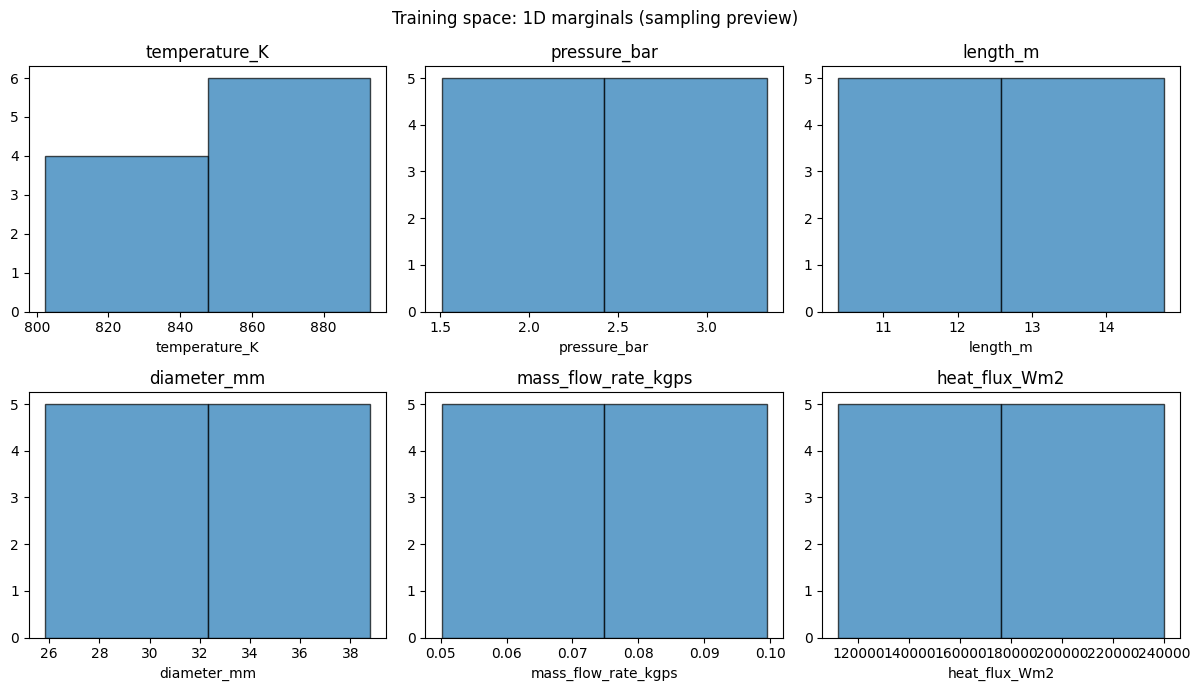

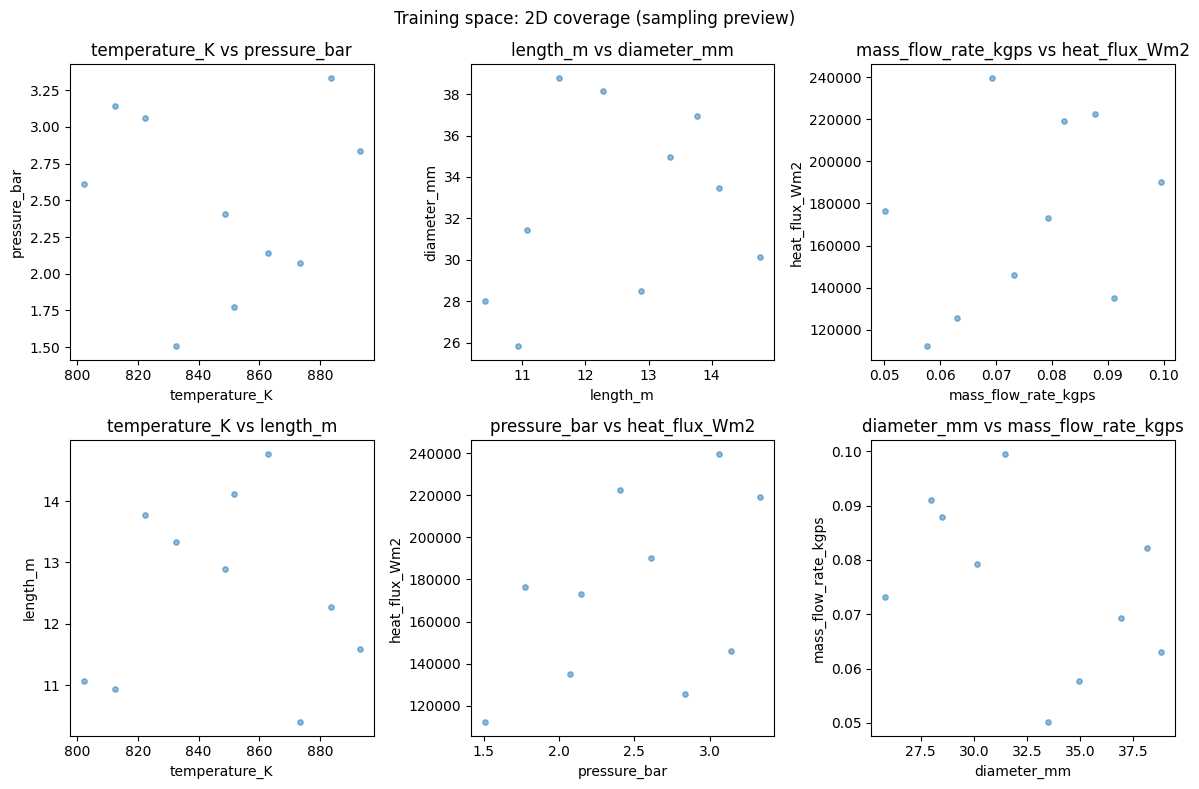

[OK] Design: 10 combinations × 6 parameters.
     Good LHS/random: 1D histograms fairly uniform, 2D points well spread.


In [4]:
# Generate the same parameter combinations that will be used in training data generation
_method = (str(SAMPLING_METHOD).strip().lower() if SAMPLING_METHOD else 'random')
if _method == 'latin': _method = 'latin_hypercube'
if _method == 'latin_hypercube':
    param_combinations = generator.generate_parameter_combinations_lhs(
        MAX_COMBINATIONS, random_sample_bounds=RANDOM_SAMPLE_BOUNDS, seed=LHS_SEED)
else:
    param_combinations = generator.generate_parameter_combinations(
        max_combinations=MAX_COMBINATIONS, random_sample=(_method == 'random'),
        random_sample_bounds=RANDOM_SAMPLE_BOUNDS)

# Build DataFrame for plotting (use display units: bar, mm)
rows = []
for p in param_combinations:
    rows.append({
        'temperature_K': p['temperature_K'],
        'pressure_bar': p['pressure_Pa'] / 1e5,
        'length_m': p['length_m'],
        'diameter_mm': p['diameter_m'] * 1000,
        'mass_flow_rate_kgps': p['mass_flow_rate_kgps'],
        'heat_flux_Wm2': p['heat_flux_Wm2']})
df_design = pd.DataFrame(rows)
param_names = list(df_design.columns)

# 1D marginals: uniformity of exploration per parameter
fig1, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for i, col in enumerate(param_names):
    axes[i].hist(df_design[col], bins=min(30, len(df_design)//5), edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
plt.suptitle('Training space: 1D marginals (sampling preview)', fontsize=12)
plt.tight_layout()
if IF_SAVE_PLOTS:
    generator.output_dir.mkdir(parents=True, exist_ok=True)
    fig1.savefig(generator.output_dir / 'training_space_1d_preview.png', dpi=150, bbox_inches='tight')
if IF_SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig1)

# 2D pairwise scatter: space-filling quality (selected pairs)
pairs = [('temperature_K', 'pressure_bar'), ('length_m', 'diameter_mm'), ('mass_flow_rate_kgps', 'heat_flux_Wm2'),
         ('temperature_K', 'length_m'), ('pressure_bar', 'heat_flux_Wm2'), ('diameter_mm', 'mass_flow_rate_kgps')]
fig2, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df_design[x], df_design[y], alpha=0.5, s=15)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}')
plt.suptitle('Training space: 2D coverage (sampling preview)', fontsize=12)
plt.tight_layout()
if IF_SAVE_PLOTS:
    generator.output_dir.mkdir(parents=True, exist_ok=True)
    fig2.savefig(generator.output_dir / 'training_space_2d_preview.png', dpi=150, bbox_inches='tight')
if IF_SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig2)

print(f"[OK] Design: {len(df_design)} combinations × {len(param_names)} parameters.")
print(f"     Good LHS/random: 1D histograms fairly uniform, 2D points well spread.")

## Step 3: Generate Training Data

Run the data generation process. This will:
- Run multiple PFR simulations with varied parameters
- Collect features and targets at each simulation point
- Save data incrementally to prevent loss
- Generate metadata for reproducibility

**Note**: This may take 5-30 minutes depending on the number of simulations.

In [5]:
# Generate dataset
print("=" * 60)
print("Starting Training Data Generation...")
print("=" * 60)
print(f"Reactants: {REACTANTS}")
print(f"Max combinations per reactant: {MAX_COMBINATIONS}")
print(f"Sampling method: {SAMPLING_METHOD}")
print(f"Save interval: {SAVE_INTERVAL} simulations")
print("=" * 60)

start_time = time.time()

dataset = generator.generate_dataset(
    reactants=REACTANTS,
    max_combinations_per_reactant=MAX_COMBINATIONS,
    save_interval=SAVE_INTERVAL,
    random_sample_bounds=RANDOM_SAMPLE_BOUNDS,
    sampling_method=SAMPLING_METHOD,
    lhs_seed=LHS_SEED,
    save_metadata=IF_SAVE_METADATA,
    save_training_data=IF_SAVE_TRAINING_DATA,
    save_complete_csv=IF_SAVE_COMPLETE_CSV,
)

elapsed_time = time.time() - start_time
hours = int(elapsed_time // 3600)
minutes = int((elapsed_time % 3600) // 60)
seconds = int(elapsed_time % 60)

print(f"\n[OK] Data generation completed!")
print(f"  - Total time: {hours:02d}:{minutes:02d}:{seconds:02d}")

# Calculate actual number of simulations completed
# The dataset has multiple rows per simulation (one per reactor step)
# We get the actual count from the metadata file
if dataset is not None and len(dataset) > 0:
    import glob
    metadata_files = sorted(glob.glob(str(generator.output_dir / 'metadata_*.json')), reverse=True)
    if metadata_files:
        with open(metadata_files[0], 'r') as f:
            metadata = json.load(f)
        n_simulations = metadata.get('total_simulations', len(REACTANTS) * MAX_COMBINATIONS)
    else:
        n_simulations = len(REACTANTS) * MAX_COMBINATIONS
    
    print(f"  - Simulations completed: {n_simulations}")
    print(f"  - Data points collected: {len(dataset):,}")
    if n_simulations > 0:
        print(f"  - Average time per simulation: {elapsed_time / n_simulations:.2f} seconds")
        print(f"  - Data points per simulation: {len(dataset) / n_simulations:.1f}")
    else:
        print("  - Average time: N/A (no simulations completed)")
else:
    print("  - Average time: N/A (no data collected)")


Starting Training Data Generation...
Reactants: ['n-hexane']
Max combinations per reactant: 10
Sampling method: latin
Save interval: 1 simulations

Generating training data for 1 reactants
  Sampling method: latin_hypercube
  10 parameter combinations per reactant
  Total simulations: 10
  Parallel jobs: 1 (sequential)

Processing reactant: n-hexane (sim 1/10)

[1] Running simulation for n-hexane...
  T=802.3K, P=2.61bar, L=11.1m, D=31.5mm, m=0.0995kg/s, q=190366W/m²
Gas mechanism contains 153 species and 2146 reactions
Starting simulation with 200 steps...
Progress: 0/200 (0%)
Progress: 20/200 (10%)
Progress: 40/200 (20%)
Progress: 60/200 (30%)
Progress: 80/200 (40%)
Progress: 100/200 (50%)
Progress: 120/200 (60%)
Progress: 140/200 (70%)
Progress: 160/200 (80%)
Progress: 180/200 (90%)
  [OK] Simulation 1 completed: 201 data points
[Progress] 1/10 (10.0%) | ✓ Success: 1 (100.0%) | ✗ Failed: 0 | Data points: 201 | ETA: 1.9 min

  [SAVED] Partial data saved: data\training\training_data_p